# **Deep Learning para Agricultura: Detectando Enfermedades en Plantas con CNNs**

**Taller interactivo** | Basado en: *Geetharamani & Arun Pandian (2019)*

---

**Objetivo:** Entender paso a paso cómo las redes neuronales convolucionales (CNNs) pueden "ver" y diagnosticar enfermedades en plantas.

**Duración estimada:** ~1 hora

**Estructura del taller:**

| Parte | Tema | Tiempo |
|-------|------|--------|
| I | El problema: enfermedades en cultivos | 10 min |
| II | ¿Cómo ve una computadora? Píxeles y filtros | 15 min |
| III | Arquitectura de una CNN | 15 min |
| IV | Entrenamiento: cómo aprende el modelo | 10 min |
| V | Resultados y conclusiones | 10 min |

In [1]:
# ==============================================================
# CELDA DE CONFIGURACION - Ejecutar primero
# ==============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from scipy.signal import convolve2d
import torch
import torch.nn as nn

# Colab: habilitar widgets interactivos
try:
    from google.colab import output
    output.enable_custom_widget_manager()
except ImportError:
    pass

import ipywidgets as widgets
from ipywidgets import interact

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('Entorno listo.')

Entorno listo.


---
## Parte I: El Problema

Las enfermedades en cultivos generan **pérdidas de hasta el 30% de la producción mundial** de alimentos. Detectarlas a tiempo puede salvar cosechas enteras.

El reto: un agrónomo experto no puede revisar miles de hectáreas en poco tiempo. ¿Puede una computadora ayudar?

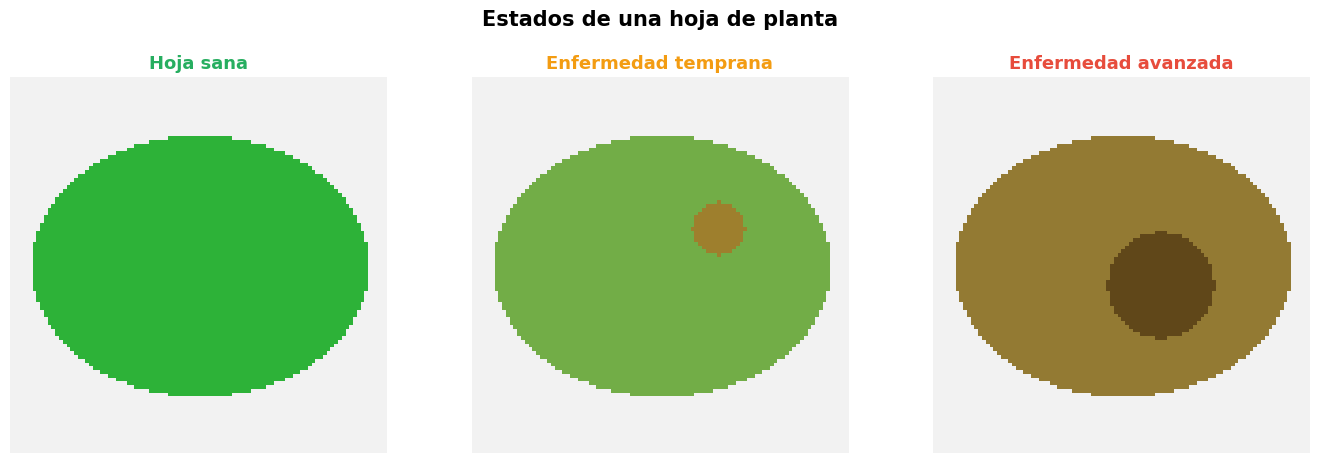

Detectar la enfermedad en la etapa temprana permite actuar antes de perder el cultivo.


In [2]:
# --- Visualizacion: estados de una hoja ---
def crear_hoja(estado='sana', size=100):
    """Genera una imagen sintetica de una hoja en distintos estados de salud."""
    img = np.ones((size, size, 3)) * 0.95  # fondo gris claro
    Y, X = np.ogrid[:size, :size]
    cx, cy = size // 2, size // 2
    # forma de la hoja (elipse)
    hoja = ((X - cx)**2 / 2000 + (Y - cy)**2 / 1200) < 1

    if estado == 'sana':
        img[hoja] = [0.18, 0.70, 0.22]
    elif estado == 'leve':
        img[hoja] = [0.45, 0.68, 0.28]
        mancha = ((X - cx - 15)**2 + (Y - cy + 10)**2) < 50
        img[mancha & hoja] = [0.62, 0.50, 0.18]
    else:  # severa
        img[hoja] = [0.58, 0.48, 0.20]
        mancha = ((X - cx - 10)**2 + (Y - cy - 5)**2) < 200
        img[mancha & hoja] = [0.38, 0.28, 0.10]
    return img

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
info = [
    ('sana',   'Hoja sana',             '#27ae60'),
    ('leve',   'Enfermedad temprana',    '#f39c12'),
    ('severa', 'Enfermedad avanzada',    '#e74c3c'),
]
for ax, (estado, titulo, color) in zip(axes, info):
    ax.imshow(crear_hoja(estado))
    ax.set_title(titulo, fontsize=13, fontweight='bold', color=color)
    ax.axis('off')

fig.suptitle('Estados de una hoja de planta', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Detectar la enfermedad en la etapa temprana permite actuar antes de perder el cultivo.')

### El Dataset PlantVillage

El paper utiliza el dataset **PlantVillage**, una colección pública de imágenes de hojas:

- **54 305 imágenes** etiquetadas
- **14 tipos de plantas** (tomate, manzana, maíz, papa, etc.)
- **39 clases** que combinan planta + estado de salud

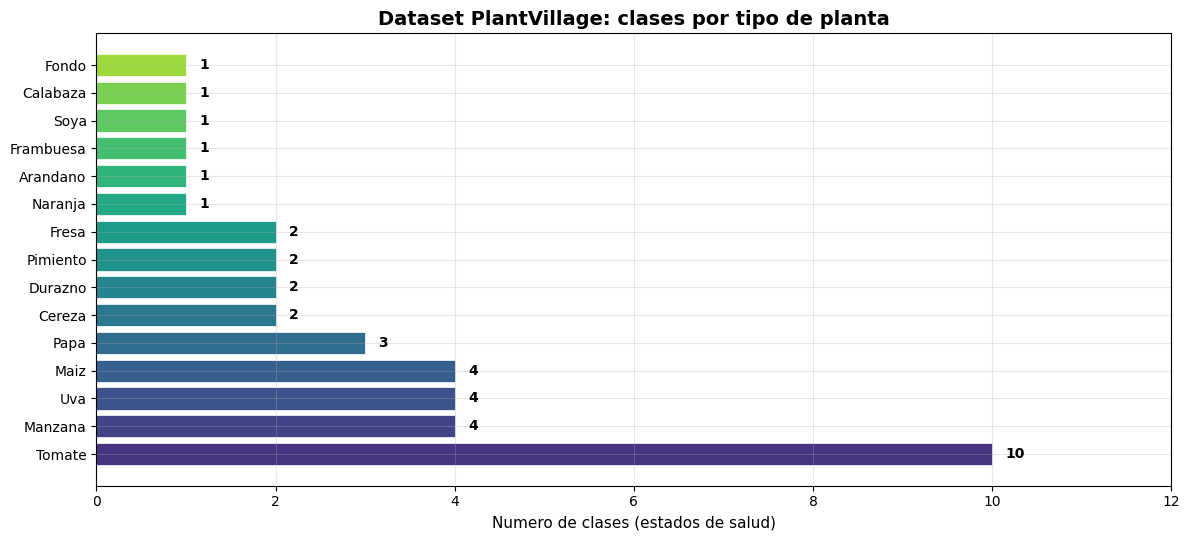

Total de clases: 39
El tomate tiene la mayor variedad de enfermedades: 10 clases.


In [3]:
# --- Visualizacion: composicion del dataset ---
CLASES = {
    'Tomate': 10, 'Manzana': 4, 'Uva': 4, 'Maiz': 4,
    'Papa': 3, 'Cereza': 2, 'Durazno': 2, 'Pimiento': 2,
    'Fresa': 2, 'Naranja': 1, 'Arandano': 1, 'Frambuesa': 1,
    'Soya': 1, 'Calabaza': 1, 'Fondo': 1,
}
plantas = list(CLASES.keys())
n_clases = list(CLASES.values())

fig, ax = plt.subplots(figsize=(12, 5.5))
colores = plt.cm.viridis(np.linspace(0.15, 0.85, len(plantas)))
bars = ax.barh(plantas, n_clases, color=colores, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, n_clases):
    ax.text(val + 0.15, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontweight='bold', fontsize=10)

ax.set_xlabel('Numero de clases (estados de salud)', fontsize=11)
ax.set_title('Dataset PlantVillage: clases por tipo de planta',
             fontsize=14, fontweight='bold')
ax.set_xlim(0, 12)
plt.tight_layout()
plt.show()

print(f'Total de clases: {sum(n_clases)}')
print(f'El tomate tiene la mayor variedad de enfermedades: {CLASES["Tomate"]} clases.')

---
## Parte II: ¿Cómo ve una computadora?

Cuando **nosotros** vemos una hoja:
1. Los ojos captan luz y color.
2. El cerebro detecta bordes, formas y texturas.
3. Combinamos esas pistas y reconocemos si está sana o enferma.

Una **Red Neuronal Convolucional (CNN)** replica este proceso en capas sucesivas.

### Paso 1 — La imagen como números

Para la computadora, una imagen es simplemente una **matriz de números** (píxeles). Cada píxel tiene un valor de intensidad.

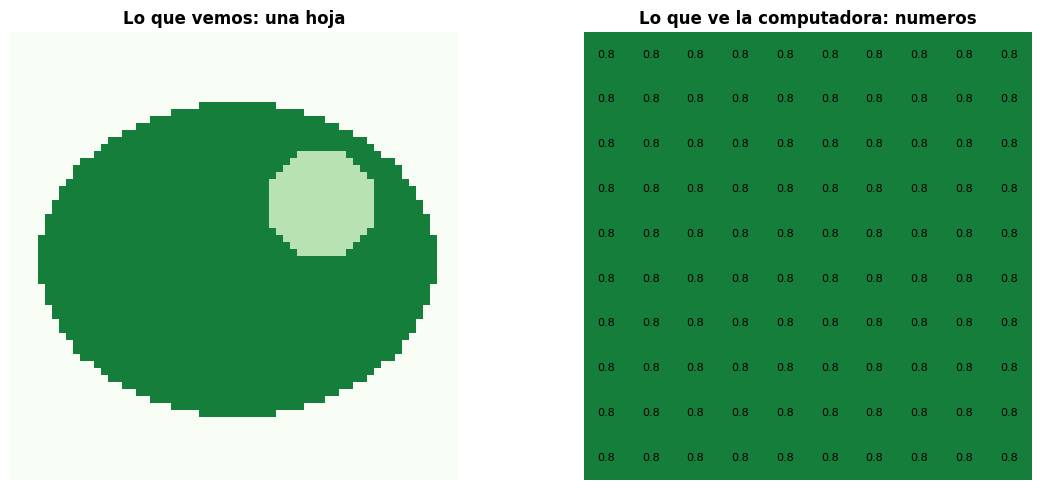

Cada pixel es un numero entre 0 (oscuro) y 1 (claro).


In [4]:
# --- Visualizacion: imagen como matriz de numeros ---
size = 64
Y, X = np.ogrid[:size, :size]
cx, cy = size // 2, size // 2

# Hoja sintetica en escala de grises
hoja_gris = np.zeros((size, size))
elipse = ((X - cx)**2 / 800 + (Y - cy)**2 / 500) < 1
hoja_gris[elipse] = 0.8
mancha = ((X - cx - 12)**2 + (Y - cy + 8)**2) < 60
hoja_gris[mancha] = 0.3

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Imagen visual
axes[0].imshow(hoja_gris, cmap='Greens', vmin=0, vmax=1)
axes[0].set_title('Lo que vemos: una hoja', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Zoom a los numeros
zona = hoja_gris[26:36, 26:36]
axes[1].imshow(zona, cmap='Greens', vmin=0, vmax=1)
for i in range(zona.shape[0]):
    for j in range(zona.shape[1]):
        axes[1].text(j, i, f'{zona[i, j]:.1f}', ha='center', va='center',
                     fontsize=8, color='black' if zona[i, j] > 0.5 else 'white')
axes[1].set_title('Lo que ve la computadora: numeros', fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()
print('Cada pixel es un numero entre 0 (oscuro) y 1 (claro).')

### Paso 2 — Filtros: la herramienta clave

Una **convolución** es una ventana pequeña (filtro o *kernel*) que se desliza sobre la imagen.
Según los valores del filtro, resalta distintas características: bordes, texturas, esquinas, etc.

Experimenta con los distintos filtros:

In [5]:
# --- Demo interactiva: tipos de filtro ---
@interact(filtro=['Bordes', 'Suavizado', 'Esquinas', 'Realce'])
def demo_filtros(filtro='Bordes'):
    img = np.zeros((12, 12))
    img[3:9, 3:9] = 1.0
    img[5:7, 5:7] = 0.4  # detalle interno

    kernels = {
        'Bordes':   np.array([[-1, -1, -1],
                              [-1,  8, -1],
                              [-1, -1, -1]]),
        'Suavizado': np.ones((3, 3)) / 9,
        'Esquinas': np.array([[ 1, -2,  1],
                              [-2,  4, -2],
                              [ 1, -2,  1]]),
        'Realce':   np.array([[ 0, -1,  0],
                              [-1,  5, -1],
                              [ 0, -1,  0]]),
    }
    descripciones = {
        'Bordes':    'Resalta cambios bruscos de intensidad.',
        'Suavizado': 'Promedia vecinos para reducir ruido.',
        'Esquinas':  'Destaca puntos donde dos bordes se cruzan.',
        'Realce':    'Aumenta el contraste de detalles finos.',
    }

    kernel = kernels[filtro]
    resultado = convolve2d(img, kernel, mode='same')

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    axes[0].imshow(img, cmap='gray', vmin=0, vmax=1)
    axes[0].set_title('Imagen original', fontweight='bold')

    im = axes[1].imshow(kernel, cmap='RdBu_r')
    for i in range(3):
        for j in range(3):
            axes[1].text(j, i, f'{kernel[i,j]:.1f}', ha='center', va='center',
                         fontsize=11, fontweight='bold')
    axes[1].set_title(f'Filtro: {filtro}', fontweight='bold')

    axes[2].imshow(resultado, cmap='hot')
    axes[2].set_title('Resultado', fontweight='bold')

    for ax in axes:
        ax.axis('off')
    fig.suptitle(descripciones[filtro], fontsize=12, y=0.02)
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='filtro', options=('Bordes', 'Suavizado', 'Esquinas', 'Realce'), va…

### Paso 3 — De píxeles a significado

Una CNN aplica **muchos filtros en secuencia**. Las primeras capas detectan patrones simples (bordes), y las capas más profundas combinan esos patrones para reconocer formas complejas (manchas, texturas, hojas completas).

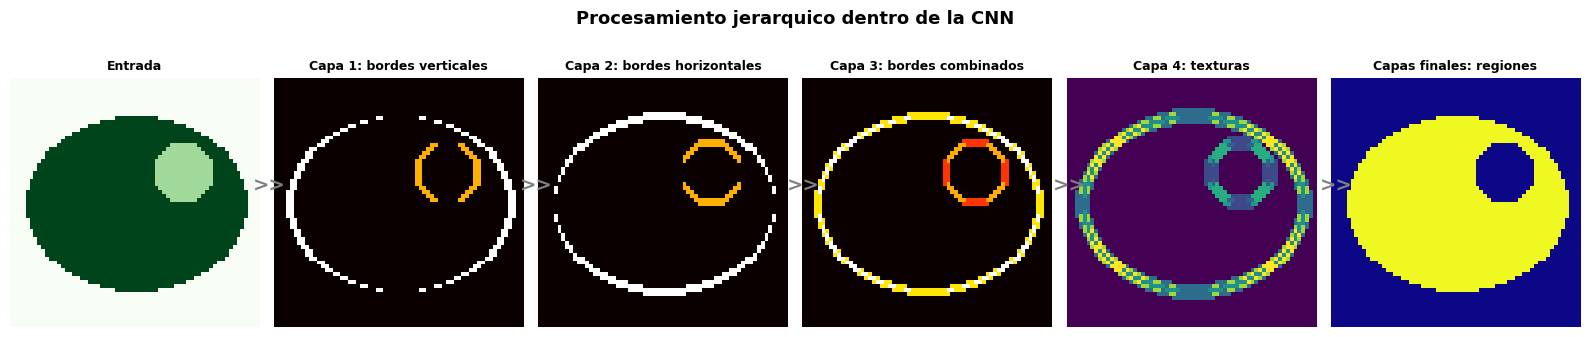

Las capas iniciales detectan bordes simples.
Las capas profundas reconocen formas y objetos completos.


In [6]:
# --- Visualizacion: procesamiento capa a capa ---
bordes_v = np.abs(np.gradient(hoja_gris, axis=1))
bordes_h = np.abs(np.gradient(hoja_gris, axis=0))
bordes   = np.sqrt(bordes_v**2 + bordes_h**2)
textura  = np.abs(np.gradient(bordes)[0]) + np.abs(np.gradient(bordes)[1])

etapas = [
    (hoja_gris,       'Greens', 'Entrada'),
    (bordes_v,        'hot',    'Capa 1: bordes verticales'),
    (bordes_h,        'hot',    'Capa 2: bordes horizontales'),
    (bordes,          'hot',    'Capa 3: bordes combinados'),
    (textura,         'viridis','Capa 4: texturas'),
    (hoja_gris > 0.5, 'plasma', 'Capas finales: regiones'),
]

fig, axes = plt.subplots(1, len(etapas), figsize=(16, 3.2))
for ax, (img, cmap, titulo) in zip(axes, etapas):
    ax.imshow(img, cmap=cmap)
    ax.set_title(titulo, fontsize=9, fontweight='bold')
    ax.axis('off')

# flechas entre subplots
for i in range(len(etapas) - 1):
    fig.text((i + 1) / len(etapas) + 0.005, 0.5, '>>',
             fontsize=14, fontweight='bold', color='gray',
             ha='center', va='center')

fig.suptitle('Procesamiento jerarquico dentro de la CNN',
             fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print('Las capas iniciales detectan bordes simples.')
print('Las capas profundas reconocen formas y objetos completos.')

---
## Parte III: Arquitectura de la CNN del paper

El modelo propuesto tiene **6 bloques convolucionales** seguidos de capas densas. Cada bloque:

1. **Convolución** — aplica filtros para extraer características.
2. **Batch Normalization** — estabiliza el aprendizaje.
3. **ReLU** — introduce no-linealidad (si el valor es negativo, lo convierte en cero).
4. **Max Pooling** — reduce el tamaño conservando lo más relevante.

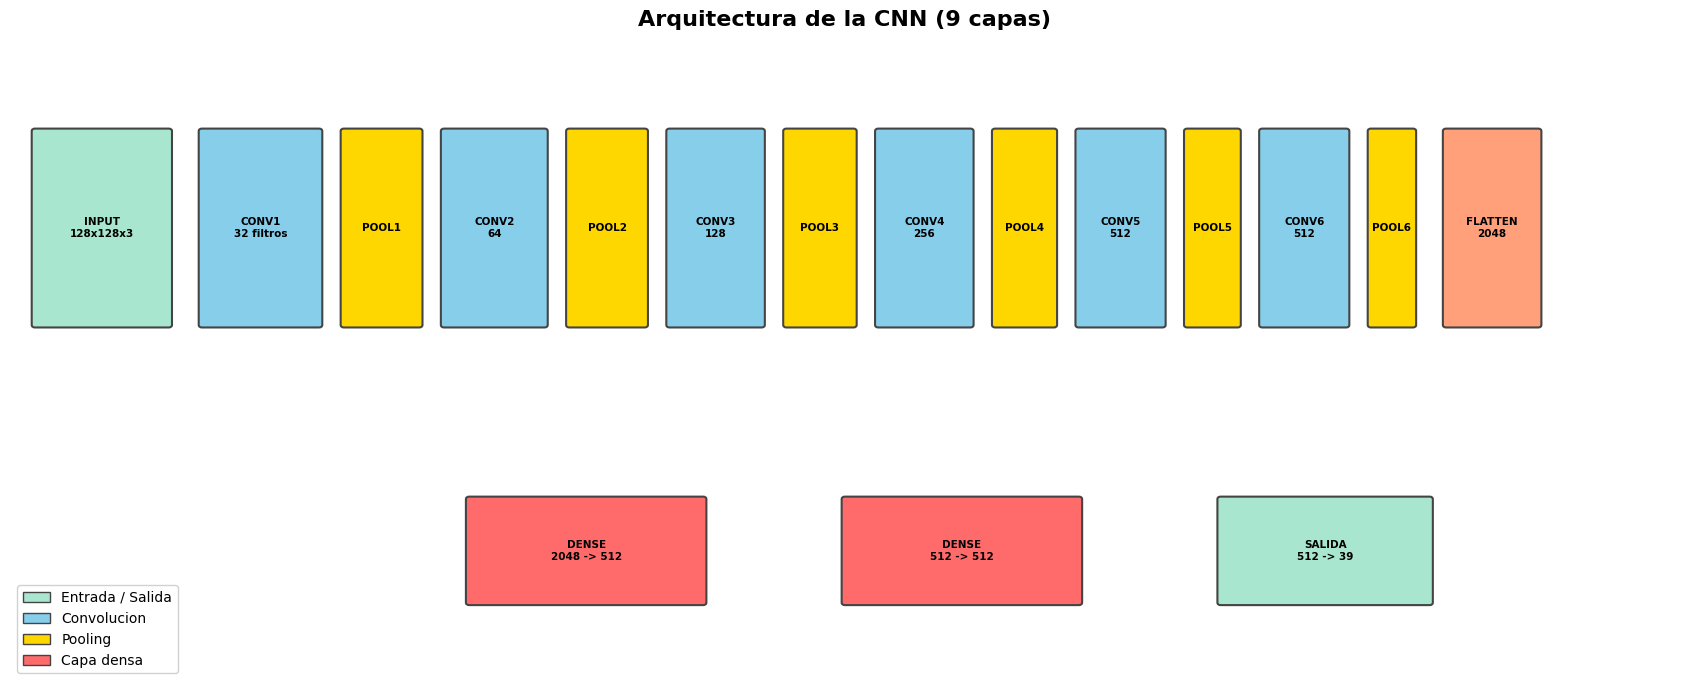

In [7]:
# --- Diagrama de la arquitectura ---
fig, ax = plt.subplots(figsize=(17, 7))
ax.set_xlim(0, 20)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Arquitectura de la CNN (9 capas)', fontsize=16, fontweight='bold')

capas = [
    ('INPUT\n128x128x3', 0.3, 5.5, 1.6, 3.0, '#a8e6cf'),
    ('CONV1\n32 filtros', 2.3, 5.5, 1.4, 3.0, '#87CEEB'),
    ('POOL1',             4.0, 5.5, 0.9, 3.0, '#FFD700'),
    ('CONV2\n64',         5.2, 5.5, 1.2, 3.0, '#87CEEB'),
    ('POOL2',             6.7, 5.5, 0.9, 3.0, '#FFD700'),
    ('CONV3\n128',        7.9, 5.5, 1.1, 3.0, '#87CEEB'),
    ('POOL3',             9.3, 5.5, 0.8, 3.0, '#FFD700'),
    ('CONV4\n256',       10.4, 5.5, 1.1, 3.0, '#87CEEB'),
    ('POOL4',            11.8, 5.5, 0.7, 3.0, '#FFD700'),
    ('CONV5\n512',       12.8, 5.5, 1.0, 3.0, '#87CEEB'),
    ('POOL5',            14.1, 5.5, 0.6, 3.0, '#FFD700'),
    ('CONV6\n512',       15.0, 5.5, 1.0, 3.0, '#87CEEB'),
    ('POOL6',            16.3, 5.5, 0.5, 3.0, '#FFD700'),
]

densas = [
    ('FLATTEN\n2048',       17.2, 5.5, 1.1, 3.0, '#FFA07A'),
    ('DENSE\n2048 -> 512',   5.5, 1.2, 2.8, 1.6, '#FF6B6B'),
    ('DENSE\n512 -> 512',   10.0, 1.2, 2.8, 1.6, '#FF6B6B'),
    ('SALIDA\n512 -> 39',   14.5, 1.2, 2.5, 1.6, '#a8e6cf'),
]

for nombre, x, y, w, h, color in capas + densas:
    rect = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.04',
                          facecolor=color, edgecolor='#444', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, nombre,
            ha='center', va='center', fontsize=7.5, fontweight='bold')

leyenda = [
    mpatches.Patch(facecolor='#a8e6cf', edgecolor='#444', label='Entrada / Salida'),
    mpatches.Patch(facecolor='#87CEEB', edgecolor='#444', label='Convolucion'),
    mpatches.Patch(facecolor='#FFD700', edgecolor='#444', label='Pooling'),
    mpatches.Patch(facecolor='#FF6B6B', edgecolor='#444', label='Capa densa'),
]
ax.legend(handles=leyenda, loc='lower left', fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.show()

### Anatomía de un bloque convolucional

Veamos qué ocurre dentro de cada bloque usando un ejemplo visual con la operación **Max Pooling**: de una región 2x2, conserva solo el valor más alto.

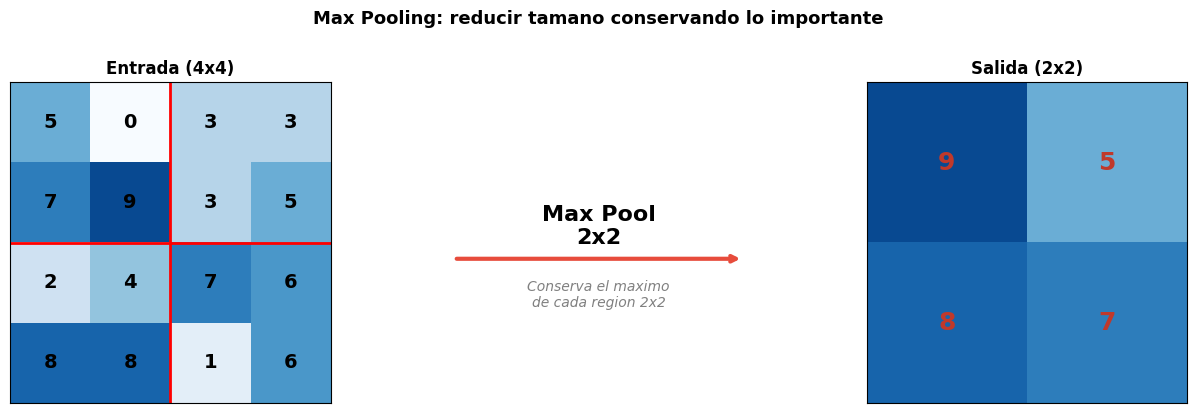

In [8]:
# --- Visualizacion: Max Pooling paso a paso ---
np.random.seed(0)
entrada = np.random.randint(0, 10, (4, 4)).astype(float)
salida = np.zeros((2, 2))
for i in range(2):
    for j in range(2):
        salida[i, j] = entrada[2*i:2*i+2, 2*j:2*j+2].max()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Entrada
axes[0].imshow(entrada, cmap='Blues', vmin=0, vmax=10)
for i in range(4):
    for j in range(4):
        axes[0].text(j, i, f'{int(entrada[i,j])}', ha='center', va='center',
                     fontsize=14, fontweight='bold')
axes[0].set_title('Entrada (4x4)', fontsize=12, fontweight='bold')
axes[0].set_xticks([]); axes[0].set_yticks([])
# Lineas de agrupacion
axes[0].axhline(1.5, color='red', lw=2)
axes[0].axvline(1.5, color='red', lw=2)

# Flecha
axes[1].axis('off')
axes[1].text(0.5, 0.55, 'Max Pool\n2x2', ha='center', va='center',
             fontsize=16, fontweight='bold')
axes[1].annotate('', xy=(0.85, 0.45), xytext=(0.15, 0.45),
                 arrowprops=dict(arrowstyle='->', lw=3, color='#e74c3c'))
axes[1].text(0.5, 0.3, 'Conserva el maximo\nde cada region 2x2',
             ha='center', fontsize=10, style='italic', color='gray')

# Salida
axes[2].imshow(salida, cmap='Blues', vmin=0, vmax=10)
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, f'{int(salida[i,j])}', ha='center', va='center',
                     fontsize=18, fontweight='bold', color='#c0392b')
axes[2].set_title('Salida (2x2)', fontsize=12, fontweight='bold')
axes[2].set_xticks([]); axes[2].set_yticks([])

plt.suptitle('Max Pooling: reducir tamano conservando lo importante',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [9]:
# --- Modelo en PyTorch ---
class PlantDiseaseCNN(nn.Module):
    """CNN de 9 capas basada en el paper."""
    def __init__(self, num_classes=39, dropout=0.5):
        super().__init__()
        def bloque(c_in, c_out):
            return nn.Sequential(
                nn.Conv2d(c_in, c_out, 3, padding=1),
                nn.BatchNorm2d(c_out),
                nn.ReLU(),
                nn.MaxPool2d(2, 2),
            )
        self.features = nn.Sequential(
            bloque(3, 32), bloque(32, 64), bloque(64, 128),
            bloque(128, 256), bloque(256, 512), bloque(512, 512),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(512 * 2 * 2, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

modelo = PlantDiseaseCNN()
n_params = sum(p.numel() for p in modelo.parameters())
print(f'Modelo creado. Parametros totales: {n_params:,}')

Modelo creado. Parametros totales: 5,000,487


### ¿Cómo se reducen las dimensiones?

Cada bloque de convolución + pooling reduce la imagen a la mitad. Observemos el recorrido:

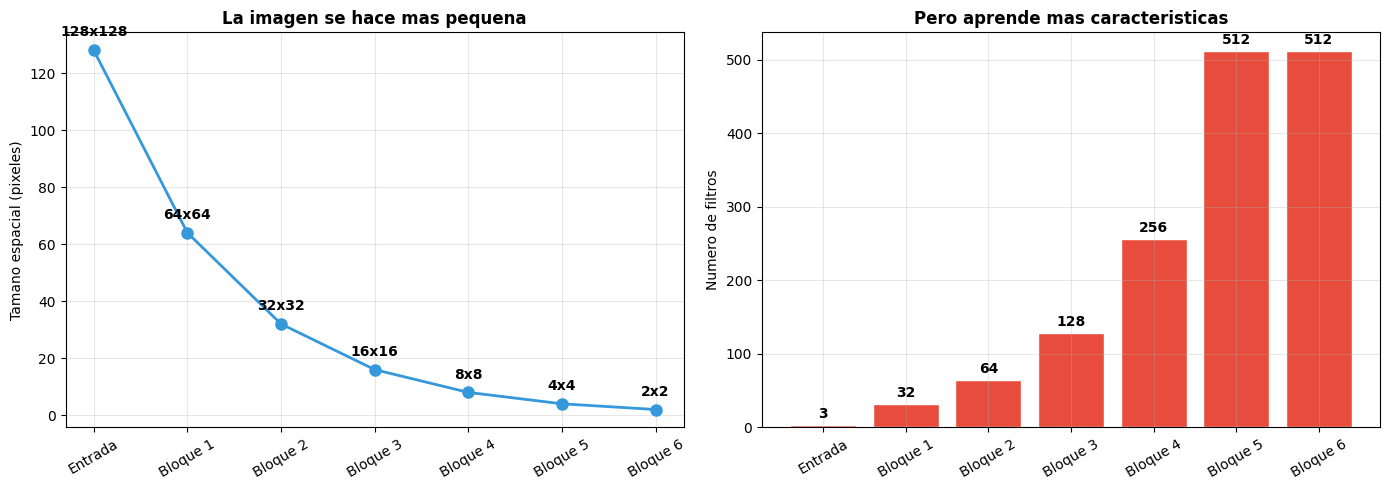

Compromiso: se pierde resolucion espacial pero se gana profundidad semantica.


In [10]:
# --- Visualizacion: reduccion de tamano capa a capa ---
dims = [128, 64, 32, 16, 8, 4, 2]
filtros = [3, 32, 64, 128, 256, 512, 512]
nombres = ['Entrada', 'Bloque 1', 'Bloque 2', 'Bloque 3',
           'Bloque 4', 'Bloque 5', 'Bloque 6']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tamano espacial
axes[0].plot(nombres, dims, 'o-', color='#3498db', linewidth=2, markersize=8)
for i, (n, d) in enumerate(zip(nombres, dims)):
    axes[0].annotate(f'{d}x{d}', (i, d), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontweight='bold')
axes[0].set_ylabel('Tamano espacial (pixeles)')
axes[0].set_title('La imagen se hace mas pequena', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

# Numero de filtros
axes[1].bar(nombres, filtros, color='#e74c3c', edgecolor='white')
for i, f in enumerate(filtros):
    axes[1].text(i, f + 10, str(f), ha='center', fontweight='bold')
axes[1].set_ylabel('Numero de filtros')
axes[1].set_title('Pero aprende mas caracteristicas', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print('Compromiso: se pierde resolucion espacial pero se gana profundidad semantica.')

---
## Parte IV: Entrenamiento — ¿cómo aprende el modelo?

El entrenamiento consiste en:
1. Mostrar imágenes al modelo y obtener su predicción.
2. Comparar la predicción con la etiqueta real (función de pérdida).
3. Ajustar los pesos del modelo para reducir el error (backpropagation).
4. Repetir durante muchas **épocas**.

Tres hiperparámetros clave que afectan el resultado:

| Hiperparámetro | ¿Qué controla? |
|---|---|
| **Learning Rate (LR)** | Qué tan grandes son los pasos de ajuste |
| **Batch Size** | Cuántas imágenes se procesan a la vez |
| **Dropout** | Qué fracción de neuronas se apagan aleatoriamente para evitar sobreajuste |

Experimenta con los valores y observa cómo cambian las curvas de entrenamiento:

In [11]:
# --- Simulador interactivo de entrenamiento ---
@interact(
    lr=widgets.FloatLogSlider(value=0.001, min=-4, max=-1, step=0.5,
                              description='Learning Rate:'),
    dropout=widgets.FloatSlider(value=0.5, min=0.0, max=0.8, step=0.1,
                                description='Dropout:'),
    epochs=widgets.IntSlider(value=50, min=20, max=100, step=10,
                             description='Epocas:'),
)
def simular_entrenamiento(lr, dropout, epochs):
    np.random.seed(42)

    # Simulacion del efecto de los hiperparametros
    lr_factor = 1 - abs(np.log10(lr) + 3) * 0.2
    acc_max = min(0.98, 0.96 * lr_factor)

    x = np.arange(epochs)
    train_acc = acc_max * (1 - np.exp(-x / (epochs / 6))) + np.random.randn(epochs) * 0.008
    sobreajuste = max(0, 0.12 - dropout * 0.18)
    val_acc = train_acc - sobreajuste + np.random.randn(epochs) * 0.01

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    # Accuracy
    axes[0].plot(x, train_acc, 'b-', label='Entrenamiento', lw=2)
    axes[0].plot(x, val_acc, 'g-', label='Validacion', lw=2)
    axes[0].fill_between(x, train_acc, val_acc, alpha=0.15, color='red', label='Brecha')
    axes[0].set_xlabel('Epoca'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].set_title('Accuracy vs Epocas', fontweight='bold')
    axes[0].set_ylim(0, 1.05)

    # Loss
    axes[1].semilogy(x, 2.5 * np.exp(-train_acc * 2), 'b-', label='Train Loss', lw=2)
    axes[1].semilogy(x, 2.8 * np.exp(-val_acc * 2), 'g-', label='Val Loss', lw=2)
    axes[1].set_xlabel('Epoca'); axes[1].set_ylabel('Loss (escala log)')
    axes[1].legend(); axes[1].set_title('Perdida vs Epocas', fontweight='bold')

    plt.tight_layout()
    plt.show()

    gap = train_acc[-1] - val_acc[-1]
    print(f'Accuracy de validacion final: {val_acc[-1]:.1%}')
    print(f'Brecha train-val: {gap:.1%}')
    if gap > 0.08:
        print('>> Sobreajuste (overfitting): el modelo memoriza en vez de generalizar.')
        print('   Intenta aumentar el dropout.')
    elif val_acc[-1] < 0.75:
        print('>> Subajuste (underfitting): el modelo no aprende lo suficiente.')
        print('   Intenta aumentar las epocas o el learning rate.')
    else:
        print('>> Buen balance entre entrenamiento y generalizacion.')

interactive(children=(FloatLogSlider(value=0.001, description='Learning Rate:', max=-1.0, min=-4.0, step=0.5),…

---
## Parte V: Resultados y conclusiones

El paper compara la CNN con métodos clásicos de Machine Learning. Veamos los resultados:

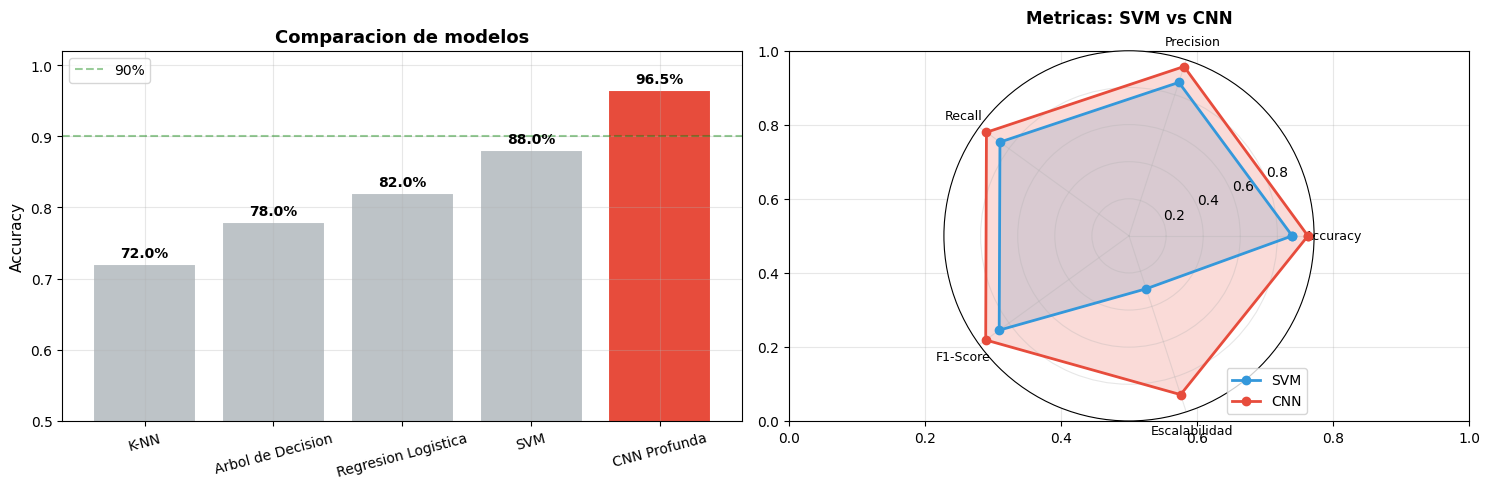

La CNN supera a todos los metodos clasicos, alcanzando 96.46% de accuracy.


In [12]:
# --- Comparacion de modelos ---
modelos  = ['K-NN', 'Arbol de Decision', 'Regresion Logistica', 'SVM', 'CNN Profunda']
accuracy = [0.72, 0.78, 0.82, 0.88, 0.9646]
colores  = ['#bdc3c7'] * 4 + ['#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Barras
bars = axes[0].bar(modelos, accuracy, color=colores, edgecolor='white', linewidth=1.5)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_title('Comparacion de modelos', fontsize=13, fontweight='bold')
axes[0].set_ylim(0.5, 1.02)
axes[0].axhline(y=0.9, color='green', ls='--', alpha=0.4, label='90%')
axes[0].legend()
for bar, acc in zip(bars, accuracy):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f'{acc:.1%}', ha='center', fontweight='bold', fontsize=10)
axes[0].tick_params(axis='x', rotation=15)

# Radar
categorias = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Escalabilidad']
svm_vals = [0.88, 0.87, 0.86, 0.865, 0.3]
cnn_vals = [0.9646, 0.96, 0.95, 0.955, 0.9]
angulos = np.linspace(0, 2 * np.pi, len(categorias), endpoint=False).tolist()
angulos += angulos[:1]
svm_vals += svm_vals[:1]
cnn_vals += cnn_vals[:1]

ax2 = fig.add_subplot(122, projection='polar')
ax2.plot(angulos, svm_vals, 'o-', label='SVM', color='#3498db', lw=2)
ax2.fill(angulos, svm_vals, alpha=0.2, color='#3498db')
ax2.plot(angulos, cnn_vals, 'o-', label='CNN', color='#e74c3c', lw=2)
ax2.fill(angulos, cnn_vals, alpha=0.2, color='#e74c3c')
ax2.set_xticks(angulos[:-1])
ax2.set_xticklabels(categorias, fontsize=9)
ax2.set_title('Metricas: SVM vs CNN', pad=20, fontweight='bold')
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

print('La CNN supera a todos los metodos clasicos, alcanzando 96.46% de accuracy.')

### Ideas clave del taller

1. **Las CNN procesan imágenes de forma jerárquica:** bordes, texturas y finalmente objetos completos.
2. **La convolución es una ventana deslizante** que busca patrones específicos en la imagen.
3. **El pooling reduce dimensiones** conservando la información más relevante.
4. **Los hiperparámetros (LR, dropout) son cruciales** para lograr un buen balance entre aprender y generalizar.
5. **La CNN del paper logró 96.46% de accuracy**, superando ampliamente a los métodos tradicionales.

### Aplicaciones del mundo real

- Aplicaciones móviles para que agricultores diagnostiquen enfermedades en campo.
- Monitoreo automatizado con drones.
- Robots de tratamiento selectivo que aplican pesticida solo donde se detecta enfermedad.
- Sistemas de alerta temprana en agricultura de precisión.

---

**Referencia:** Geetharamani, G., & Arun Pandian, J. (2019). *Identification of plant leaf diseases using a nine-layer deep convolutional neural network.* Computers & Electrical Engineering, 76, 323-338.